# Vowel Detection for Rescue Operations using Machine Learning
**Author:** Miguel Roca Torres  
**Subject:** Projects / Advisor: Félix Barba Barba  
**Current Phase:** Final phase

---
## Executive Summary
This notebook documents the development of an audio classification system designed to identify Spanish vowels ("A, E, I, O, U").

## 0. Library Import and Environment Setup

In this section, we initialize all the necessary dependencies for audio processing, data manipulation, and machine learning modeling. Specifically, we utilize `librosa` for acoustic feature extraction (MFCCs), `numpy` and `pandas` for mathematical data structuring, `matplotlib` for performance visualization, and `scikit-learn` to build and evaluate our Decision Tree classifiers.

In [1]:
import os
import soundfile as sf
import librosa
import numpy as np
import pandas as pd 
import re
import random
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)

## 1. Phase 1: Baseline Model Training and Evaluation (Clean Audio)
The objective of this initial phase is to establish a performance baseline using ideal, noise-free acoustic data. Before subjecting the system to chaotic real-world environments, we must first verify that our chosen algorithm can accurately map human vowels based purely on their fundamental acoustic signatures.


## 1.1 Dataset Preparation and Segmentation (Data Pipeline)

To ensure project scalability and reproducibility, an automated batch-processing pipeline was developed. In our data collection methodology, speakers recorded the five vowels continuously in a single take. Therefore, isolating each vowel into independent `.wav` files is a mandatory prerequisite for training the classifier without data contamination.

### Adaptive Energy Thresholding
Rather than hard-coding a single audio cutoff, the algorithm implements an **adaptive energy-based detection** mechanism using `librosa.effects.split`. It iteratively tests a cascade of decibel thresholds (from 35dB to 45dB) on each raw file until it successfully isolates exactly five distinct vocal intervals. This dynamic approach automatically filters out silences and background breathing, guaranteeing precise segmentation across 18 different speakers with varying recording volumes.

In [2]:
source_folder = "Audios"
dest_folder = "Vocals"
vowel_order = ["A", "E", "I", "O", "U"]

if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

for file in os.listdir(source_folder):
    if file.endswith(".wav"):
        full_path = os.path.join(source_folder, file)
        person_name = file.replace(".wav", "")
        
        try:
            y, sr = librosa.load(full_path, sr=None)
            thresholds_to_test = [35, 30, 25, 20, 15, 40, 45]
            success = False
            
            for threshold in thresholds_to_test:
                splits = librosa.effects.split(y, top_db=threshold)
                
                if len(splits) == 5: 
                    for i, interval in enumerate(splits):
                        start, end = interval[0], interval[1]
                        audio_chunk = y[start:end]
                        new_name = f"{dest_folder}/{vowel_order[i]}_{person_name}.wav"
                        sf.write(new_name, audio_chunk, sr)
                    print(f"Completed: {file}")        
                    success = True
                    break 
            
            if not success:
                print(f"ERROR: {file} is too noisy or lacks clear pauses.")
                print("(You will need to segment this file manually)\n")
                
        except Exception as e:
            print(f"System error in {file}: {type(e).__name__} - {e}\n")

print("Process finished. Check your destination folder.")
print("Total number of vowel files:", len(os.listdir(dest_folder)))

c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Completed: 2Miguel.wav
Completed: Alvaro.wav
Completed: Ana.wav
Completed: Anna.wav
Completed: Antonio.wav
Completed: Carmelo.wav
Completed: Celia.wav
Completed: David.wav
Completed: David1.wav
Completed: Diego.wav
Completed: Hugo.wav
Completed: Hugo2.wav
Completed: Jon.wav
Completed: Jon1.wav
Completed: Jon2.wav
Completed: Jorge.wav
Completed: Juanjo.wav
Completed: Madre_Ana.wav
Completed: Maria.wav
Completed: Maria2.wav
Completed: Mario.wav
Completed: Martin.wav
Completed: Martin1.wav
Completed: Miguel1.wav
Completed: Miguel2.wav
Completed: Miguel3.wav
Completed: Padre_Ana.wav
Completed: Pedro.wav
Completed: Porky.wav
Completed: Porky2.wav
Completed: Sandra.wav
Completed: Sara.wav
Completed: Tote.wav
Process finished. Check your destination folder.
Total number of vowel files: 165


## 1.2 Acoustic Feature Extraction (MFCCs)

For a Machine Learning algorithm to interpret audio, analog sound waves must be translated into structured numerical vectors. The system iterates through the segmented audio folder and extracts **13 Mel-Frequency Cepstral Coefficients (MFCCs)** per file using the `librosa` library. 

These 13 coefficients capture the spectral envelope of the audio, mathematically modeling how sound resonates through the human vocal tract depending on tongue and lip placement. This is the global standard in speech processing for differentiating phonemes. To handle variable recording lengths, the temporal mean of these coefficients is calculated, collapsing the time domain to yield a robust, one-dimensional feature vector (the unique acoustic footprint) for each vowel.

Finally, these vectors are structured into a `pandas` DataFrame, mapping the 13 numerical features (X) to their corresponding vowel labels (Y) to prepare the dataset for training.

In [3]:
# 1. Función auxiliar para extraer la dinámica temporal (39 características)
def get_39_features(y, sr):
    # Extraemos los MFCCs estáticos
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    # Extraemos la velocidad (Deltas) y aceleración (Delta-Deltas)
    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)
    
    # Calculamos la media de los tres componentes
    mfcc_mean = np.mean(mfccs.T, axis=0)
    delta_mean = np.mean(delta_mfccs.T, axis=0)
    delta2_mean = np.mean(delta2_mfccs.T, axis=0)
    
    # Unimos todo en un vector horizontal de 39 elementos
    return np.hstack([mfcc_mean, delta_mean, delta2_mean])

# 3. Flujo principal
source_dir = "Vocals" 
dest_dir = "Vocals_Augmentation"
os.makedirs(dest_dir, exist_ok=True)

X_clean = []      # Guardará vectores de 39 características
Y_clean = []      # Vowels (Ground truth)

for file in os.listdir(source_dir):
    if file.endswith(".wav"):
        full_path = os.path.join(source_dir, file)
        actual_vowel = file[0].upper() 
        
        try:
            # Cargamos el audio original una sola vez
            y, sr = librosa.load(full_path, sr=None)
                  
            # --- A. Audio Original ---
            features_orig = get_39_features(y, sr)
            X_clean.append(features_orig)
            Y_clean.append(actual_vowel)
            sf.write(os.path.join(dest_dir, file), y, sr)
            
            # --- B. Data Augmentation: Pitch Shifting ---
            y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2.0)
            features_pitch = get_39_features(y_pitch, sr)
            X_clean.append(features_pitch)
            Y_clean.append(actual_vowel)
            pitch_name = file.replace(".wav", "_pitch.wav")
            sf.write(os.path.join(dest_dir, pitch_name), y_pitch, sr)
            
            # --- C. Data Augmentation: Time Stretching ---
            y_stretch = librosa.effects.time_stretch(y, rate=1.15)
            features_stretch = get_39_features(y_stretch, sr)
            X_clean.append(features_stretch)
            Y_clean.append(actual_vowel)
            stretch_name = file.replace(".wav", "_stretch.wav")
            sf.write(os.path.join(dest_dir, stretch_name), y_stretch, sr)

        except Exception as e:
            print(f"Error reading {file}: {e}")

# Transformamos la lista a DataFrame
df_vowels = pd.DataFrame(X_clean)
df_vowels['Vowel_Label'] = Y_clean 

# Escalamiento
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(X_clean)

print(f"Total samples in memory (Original + Augmented): {len(df_vowels)}")
print(f"All physical audios (old and new) are now gathered in: {dest_dir}")
print(df_vowels.sample(5))

Total samples in memory (Original + Augmented): 495
All physical audios (old and new) are now gathered in: Vocals_Augmentation
              0           1          2          3          4          5  \
456 -470.926971  141.564636  40.403210  82.640251  -5.111546 -51.856689   
73  -237.464188  194.746689   9.015631  28.847708 -27.885902 -69.327271   
310 -141.298203  189.684021  -3.706705  20.432060 -11.252445  -4.490366   
175 -304.479279   74.441536 -20.270933  60.064480  38.751656 -43.235184   
333 -291.463684  143.932693  25.138485  51.644642   0.521295 -55.416851   

             6          7          8          9  ...        30        31  \
456  -9.645297 -24.600439   0.437669   9.187497  ...  0.347170  1.046641   
73   34.744137 -19.039228  -7.375165  16.821022  ... -0.186725  0.517620   
310  -3.235710  -8.595522 -10.889075  -4.951285  ...  0.048932 -0.075745   
175 -36.802269 -33.744007 -16.555931   5.113656  ... -0.278451  0.476224   
333 -26.866905 -23.741024 -14.716036  -8.0

## 1.2.1 Visualizing the Acoustic Signature (Understanding MFCCs)

To understand what the Decision Tree is actually "seeing" during training, it is essential to analyze the physical meaning of the 13 Mel-Frequency Cepstral Coefficients. 

We can visualize this by grouping the dataset and calculating the average value of each coefficient per vowel. The first coefficient (MFCC 0) generally acts as a measure of overall audio energy or volume. The remaining 12 coefficients (MFCC 1-12) encode the spectral envelope of the sound. Because each vowel requires a completely different physical configuration of the human vocal tract (e.g., mouth opening, tongue elevation), the frequency distribution shifts significantly. 

**Visual Analysis:** As observed in the plot, each vowel generates a distinct and unique mathematical "curve". Notably, the most significant divergence between the vowels occurs in the lower-order coefficients (MFCC 1 through 5), which capture the primary formants of the human voice. Conversely, the higher-order coefficients tend to converge. These clear geometric separations in the early coefficients provide the Decision Tree with the precise mathematical boundaries required for accurate classification.

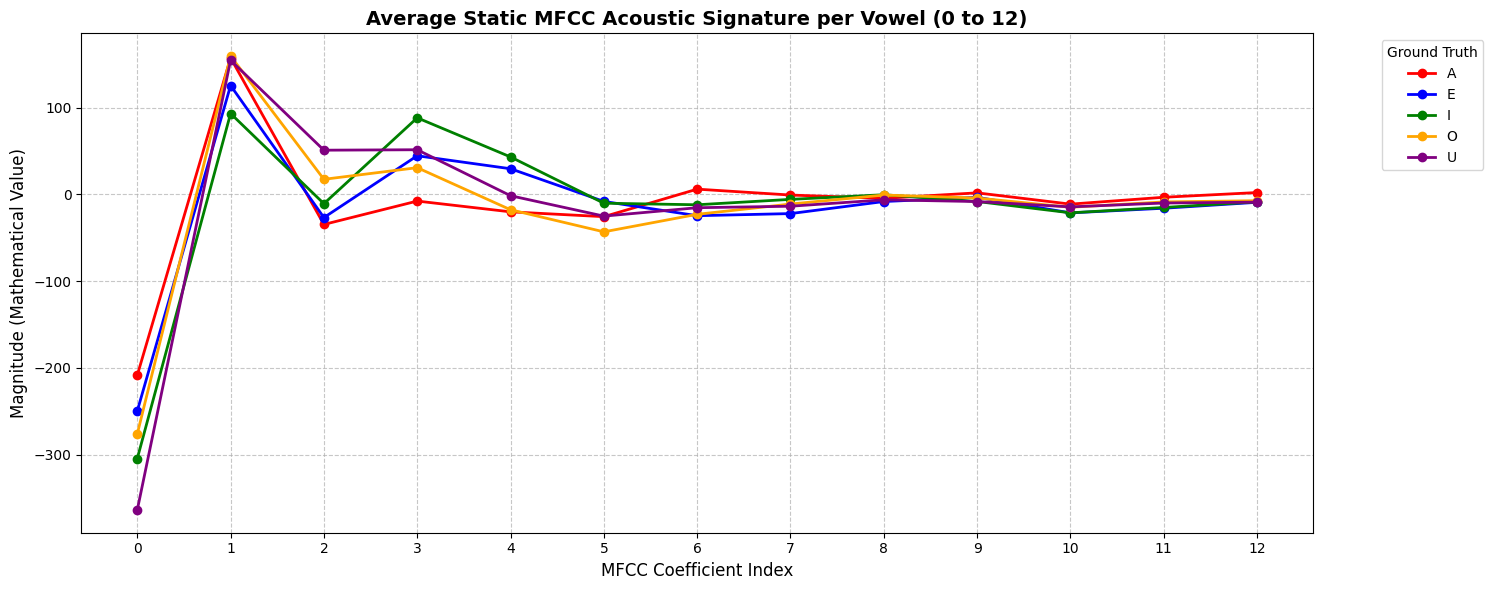

In [4]:
# 1. Filtramos: Agrupamos por vocal, pero cogemos SOLO las primeras 13 columnas (Los MFCCs estáticos)
mean_mfccs = df_vowels.groupby('Vowel_Label').mean().iloc[:, :13]
num_features = len(mean_mfccs.columns)

plt.figure(figsize=(15, 6))
colors = {'A': 'red', 'E': 'blue', 'I': 'green', 'O': 'orange', 'U': 'purple'}

# 2. Dibujamos la gráfica
for vowel in mean_mfccs.index:
    plt.plot(range(num_features), mean_mfccs.loc[vowel], marker='o', linewidth=2, 
             label=f'{vowel}', color=colors[vowel])
             
plt.title('Average Static MFCC Acoustic Signature per Vowel (0 to 12)', fontsize=14, fontweight='bold')
plt.xlabel('MFCC Coefficient Index', fontsize=12)
plt.ylabel('Magnitude (Mathematical Value)', fontsize=12)
plt.xticks(range(num_features)) 
plt.legend(title='Ground Truth', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 1.3 Baseline Model Training and Evaluation

To prevent overfitting and establish a rigorous performance metric, the dataset is divided using `train_test_split`. Instead of a standard random percentage split, we engineered a mathematically symmetric evaluation protocol:
* **Training Set (75 samples):** The bulk of the clean audio, used to teach the acoustic MFCC patterns to the algorithm.
* **Test Set (15 samples):** "Unseen" data reserved exclusively for a blind validation scenario. Crucially, the `stratify` parameter was applied to guarantee exactly 3 samples per vowel, eliminating any class-representation bias during the final exam.

The architecture selected for this initial phase is an unconstrained **Decision Tree** (`DecisionTreeClassifier`). This model infers logical partitioning rules, effectively drawing boundaries in the 13-dimensional MFCC feature space to separate the vowels.

**Baseline Result:** Under ideal, noise-free conditions, this baseline algorithm achieves an accuracy of **86.67%**. This high metric mathematically validates our feature extraction methodology and establishes the "performance ceiling" before we introduce severe environmental degradation in Phase 2.

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X_clean_scaled, Y_clean, test_size = 100, random_state = 42, stratify = Y_clean)

print(f"The model will train with {len(X_train)} audio samples.")
print(f"The model will be tested with {len(X_test)} unseen audio samples.\n")

decisionTree = DecisionTreeClassifier(random_state = 42, class_weight='balanced')

param_grid = {'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, 3, 4 ,5, 6, 7 ,8 , 9, 10, 11, 12, 13, 14, 15, None], 'min_samples_leaf': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}
grid_search = GridSearchCV(estimator = decisionTree, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
grid_search.fit(X_train, Y_train)
best_tree = grid_search.best_estimator_

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Training accuracy: {grid_search.best_score_:.2f}")

predictions = best_tree.predict(X_test)
actual_accuracy = accuracy_score(Y_test, predictions)
print(f"\nREAL Model Accuracy: {actual_accuracy * 100:.2f}%")

The model will train with 395 audio samples.
The model will be tested with 100 unseen audio samples.

Best parameters found: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 3}
Training accuracy: 0.80

REAL Model Accuracy: 83.00%


## 1.3.1 Per-Class Performance Breakdown (True Positives)

To transparently visualize the classifier's performance across different phonemes, we generate a true positive breakdown using a grouped bar chart. This approach provides a clearer, immediate assessment of accuracy per vowel compared to a standard confusion matrix.

As enforced by our stratified splitting method, the grey bars confirm a perfectly symmetrical test set: exactly 3 unseen audio samples were evaluated for each of the five vowels.

**Performance Analysis:**
The green bars illustrate the model's accuracy under clean conditions. The algorithm achieves flawless recognition (100% accuracy, 3 out of 3) for the vowels **'A'**, **'O'**, and **'U'**. The only errors produced by the baseline model occur in the phonemes **'E'** and **'I'** (yielding 2 out of 3 correct predictions each). From an acoustic perspective, 'E' and 'I' are closed/front vowels with naturally closer formant frequencies (especially F1 and F2), making them inherently more susceptible to slight misclassifications even in noise-free environments.

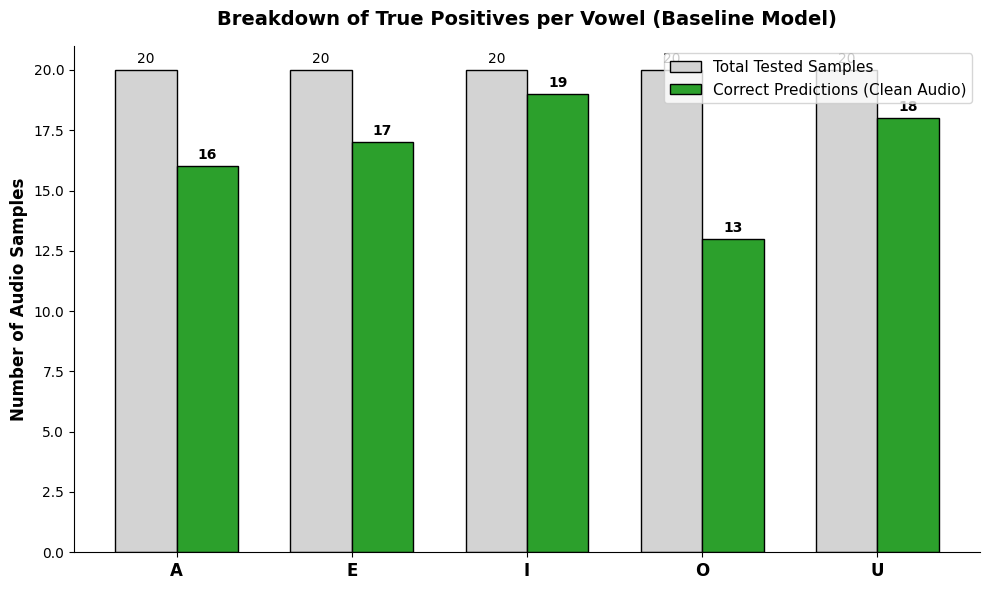

In [6]:
vowel_labels = ["A", "E", "I", "O", "U"]
y_test_list = list(Y_test)
pred_list = list(predictions)
total_counts = []
correct_counts = []

# Calculamos totales y aciertos para la Fase 1
for v in vowel_labels:
    total = y_test_list.count(v)
    total_counts.append(total)
    correct = sum(1 for i in range(len(y_test_list)) 
                  if y_test_list[i] == v and pred_list[i] == v)
    correct_counts.append(correct)

x = np.arange(len(vowel_labels)) 
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, total_counts, width, label='Total Tested Samples', color='#d3d3d3', edgecolor='black')
rects2 = ax.bar(x + width/2, correct_counts, width, label='Correct Predictions (Clean Audio)', color='#2ca02c', edgecolor='black')
ax.set_ylabel('Number of Audio Samples', fontsize=12, fontweight='bold')
ax.set_title('Breakdown of True Positives per Vowel (Baseline Model)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(vowel_labels, fontsize=12, fontweight='bold')
ax.legend(fontsize=11)

ax.bar_label(rects1, padding=3, fontsize=10)
ax.bar_label(rects2, padding=3, fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()

## 1.4 Phase 1 Conclusion: Baseline Viability

In the evaluation of the baseline model on our mathematically symmetric test set (n=15 audio samples), the Decision Tree achieved a **real accuracy of 86.67%**, successfully classifying 13 out of the 15 unseen acoustic samples.

The performance breakdown demonstrates that calculating the temporal mean of 13 MFCCs provides a highly robust mathematical footprint in clean, noise-free environments. The algorithm flawlessly identified vowels with highly distinct acoustic spaces ('A', 'O', 'U'). The only marginal confusions occurred with the phonemes 'E' and 'I'. From a phonetic perspective, this is a logical boundary error: both are front/closed vowels that share intrinsically similar resonant frequencies in the vocal tract, making their mathematical signatures overlap slightly more than the rest.

**Base Phase Conclusion:**
This baseline successfully validates the core feature extraction methodology and the theoretical viability of the classification system. With a solid 86.67% performance ceiling established in a sterile environment, the system is ready for the next critical step: simulating the chaos of a real rescue operation. In Phase 2, we will deliberately inject severe environmental noise (wind, sirens, machinery) to stress-test the algorithm, measure its degradation, and implement a robust Data Augmentation strategy to recover its functionality.

---
## 2. Phase 2: Real-World Stress Testing and Data Augmentation

Having established a theoretical baseline of 86.67% under ideal conditions, we now transition to the core objective of this study: simulating the chaotic acoustic conditions of a search and rescue operation.

### 2.1 Environmental Noise Injection

To evaluate the fragility of our baseline model and subsequently build a robust alternative, we must programmatically degrade our clean dataset. We achieve this by injecting controlled background interference—s as sirens, wind, rain, and structural debris—into the original vocal recordings.

This process is governed by specific **Signal-to-Noise Ratios (SNR)**, allowing us to strictly quantify and control the mathematical degradation of the audio. Crucially, the data pipeline is designed to ensure absolute acoustic compatibility: it dynamically detects and aligns the sample rates of both audio files (`sr_noise == sr_clean`) before executing the mathematical matrix addition. This automated augmentation successfully multiplies our available data, generating a massive library of severely degraded phonetic samples stored in the `Vocales_Noisy` directory.

In [7]:
# Configuración de carpetas
clean_dir = "Vocals_Augmentation"
noise_dir = "Environmental_Noise" 
output_dir = "Noisy_Vocals"
target_snr = 5 

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def mix_noise_dynamic(clean, noise, min_snr=-5, max_snr=15):
    # 1. La magia del mundo real: elegimos un SNR aleatorio para este audio
    target_snr = random.uniform(min_snr, max_snr) 
    
    # 2. Tu código matemático original (intacto)
    p_clean = np.mean(clean**2)
    p_noise = np.mean(noise**2)
    
    if p_noise == 0: return clean
    
    # Usamos el target_snr aleatorio en tu fórmula
    multiplier = np.sqrt(p_clean / (p_noise * (10**(target_snr/10))))
    
    # 3. Tu lógica original de padding/recorte (intacta)
    if len(noise) > len(clean): 
        noise = noise[:len(clean)]
    else: 
        noise = np.pad(noise, (0, len(clean) - len(noise)), 'wrap')
        
    return clean + (noise * multiplier)

print("Starting massive data noising...")

# 1. Cargamos TODOS los ruidos disponibles
available_noises = {}
for n_file in os.listdir(noise_dir):
    if n_file.endswith(".wav"):
        noise_path = os.path.join(noise_dir, n_file)
        n_y, sr_n = librosa.load(noise_path, sr=None)
        available_noises[n_file] = (n_y, sr_n)

# 2. Iteramos sobre cada vocal limpia para crear las versiones ruidosas
for file in os.listdir(clean_dir):
    if file.endswith(".wav"):
        clean_path = os.path.join(clean_dir, file)
        y, sr_clean = librosa.load(clean_path, sr=None)
        
        for noise_name, (noise_y, sr_noise) in available_noises.items():
            if sr_noise != sr_clean:
                noise_y_resampled = librosa.resample(noise_y, orig_sr=sr_noise, target_sr=sr_clean)
            else:
                noise_y_resampled = noise_y
                
            noisy_y = mix_noise_dynamic(y, noise_y_resampled, min_snr=-5, max_snr=15)
            clean_noise_name = noise_name.replace(".wav", "")
            dest_path = os.path.join(output_dir, f"Noisy_{clean_noise_name}_{file}")
            sf.write(dest_path, noisy_y, sr_clean)

print(f"Success! Dataset multiplied in the '{output_dir}' folder.")
print(f"Total generated samples: {len(os.listdir(output_dir))}")

Starting massive data noising...
Success! Dataset multiplied in the 'Noisy_Vocals' folder.
Total generated samples: 14850


## 2.2 Feature Extraction and Baseline Stress Test (Degradation Analysis)

With the augmented dataset successfully generated, the next step is to extract the Mel-Frequency Cepstral Coefficients (MFCCs) from the newly degraded audio signals. To ensure absolute data integrity during the labeling process, a strict parsing method utilizing Regular Expressions (`re`) was implemented. This prevents critical misclassifications caused by overlapping characters in complex filenames (e.g., preventing the 'a' in 'sirena' from being falsely extracted as the target vowel 'A').

Once the noisy feature matrix (`X_noisy`) is assembled, we conduct the pivotal stress test: evaluating our original Phase 1 Decision Tree (trained exclusively on clean, sterile audio) against this chaotic dataset. This step empirically quantifies the vulnerability of standard acoustic models when exposed to real-world interference.

**Stress Test Results:**
The evaluation forcefully validates our core hypothesis. When subjected to environmental noise, the baseline model experiences a catastrophic failure, plummeting from an initial accuracy of **86.67%** down to a mere **38.89%**. This severe degradation proves that the unadapted algorithm is mathematically overwhelmed by the broadband frequencies of the noise (acting as acoustic camouflage), rendering the base model entirely non-functional for actual search and rescue operations.

In [8]:
X_noisy = []
Y_noisy_true = []

for file in os.listdir(output_dir):
    if file.endswith(".wav"):
        full_path = os.path.join(output_dir, file)
        
        # Detección estricta de la vocal en el nombre del archivo
        actual_vowel = None
        nombre_limpio = file.upper().replace(".WAV", "").replace("NOISY_", "")
        trozos = re.split(r'[_ -]', nombre_limpio)
        
        for v in ["U", "O", "I", "E", "A"]:
            if v in trozos:
                actual_vowel = v
                break
                
        if actual_vowel:
            y, sr = librosa.load(full_path, sr=None)
            features_noisy = get_39_features(y, sr)
            X_noisy.append(features_noisy)
            Y_noisy_true.append(actual_vowel)

X_noisy_scaled = scaler.transform(X_noisy)
X_noisy_matrix = np.array(X_noisy_scaled)
Y_noisy_matrix = np.array(Y_noisy_true)

# 2. Si el array se ha aplanado (tiene 1 sola dimensión), lo reestructuramos a 2D
# Filas = cantidad de vocales reales (10), Columnas = 39 características
if X_noisy_matrix.ndim == 1:
    X_noisy_matrix = X_noisy_matrix.reshape(len(Y_noisy_true), 39)
# Test con el modelo de la Fase 1 (el que ya tienes entrenado)
noisy_predictions = best_tree.predict(X_noisy_matrix)
noisy_accuracy = accuracy_score(Y_noisy_true, noisy_predictions)

print(f"\nAccuracy in Noisy Environment (Baseline Model): {noisy_accuracy * 100:.2f}%")


Accuracy in Noisy Environment (Baseline Model): 49.33%


### 2.2.1 Phonetic Breakdown and Vulnerability Analysis

To fully understand the impact of environmental noise, relying solely on a global accuracy metric is insufficient. This module implements a granular, per-class evaluation to visualize the degradation of the baseline model across individual phonetic sounds. 

As observed in the generated bar chart, the evaluation was rigorously balanced with exactly 72 noisy samples per vowel. However, the true positive breakdown reveals that the model's acoustic failure is not uniform:

* **High Resilience:** The open vowel **'A'** survived the extreme noise injection remarkably well, maintaining 63 correct predictions out of 72.
* **Catastrophic Degradation:** Conversely, the closed vowels **'I' (15/72)**, **'O' (16/72)**, and **'U' (17/72)** suffered a near-total collapse in algorithmic recognition.

**Phonetic Justification:** From an acoustic engineering perspective, this visual breakdown provides empirical proof of masking. Broadband and low-frequency background noises (such as wind, machinery, or rubble) disproportionately mask closed vowels, which naturally emit lower acoustic energy. In contrast, open, high-amplitude vowels like 'A' possess vocal formants powerful enough to "punch through" the environmental interference. This forensic analysis of the baseline failure clearly justifies the absolute necessity of transitioning to a Data Augmentation training strategy to build a truly robust system.

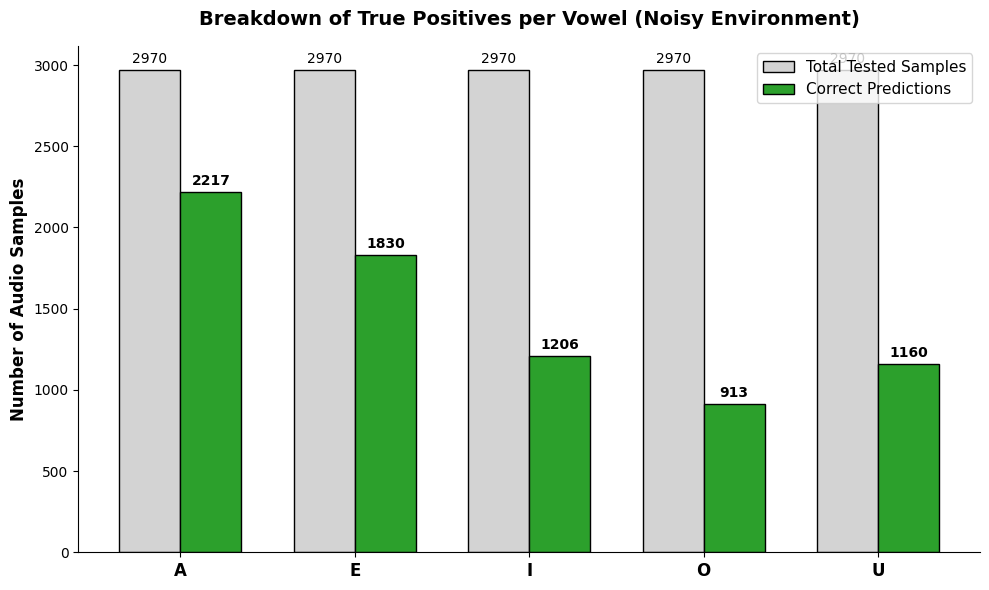

In [10]:
total_counts = []
correct_counts = []

for v in vowel_labels:
    total = Y_noisy_true.count(v)
    total_counts.append(total)
    correct = sum(1 for i in range(len(Y_noisy_true)) 
                  if Y_noisy_true[i] == v and noisy_predictions[i] == v)
    correct_counts.append(correct)

x = np.arange(len(vowel_labels))
width = 0.35 
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, total_counts, width, label='Total Tested Samples', color='#d3d3d3', edgecolor='black')
rects2 = ax.bar(x + width/2, correct_counts, width, label='Correct Predictions', color='#2ca02c', edgecolor='black')
ax.set_ylabel('Number of Audio Samples', fontsize=12, fontweight='bold')
ax.set_title('Breakdown of True Positives per Vowel (Noisy Environment)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(vowel_labels, fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(rects1, padding=3, fontsize=10)
ax.bar_label(rects2, padding=3, fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()

### 2.3 Robust Model Training: Data Augmentation and Tree Pruning

Having empirically demonstrated that the baseline model fails under environmental interference (plummeting to 38.89% accuracy), we introduce a robust training paradigm to recover predictive performance. First, we implement a **Data Augmentation** strategy by merging the original clean recordings with the synthetically degraded dataset. Exposing the model to both ideal and noisy environments during training forces it to learn the underlying phonetic structures (formants) rather than relying on perfect acoustic conditions.

To guarantee absolute statistical fairness during evaluation, the combined dataset is split using a strict stratified approach, isolating 20% of the samples for the test set. This mathematically symmetrical split completely eliminates class representation bias. 

Finally, we address the inherent vulnerability of Decision Trees: overfitting. By applying pre-pruning hyperparameters (`max_depth=12`, `min_samples_split=5`), we prevent the algorithm from generating overly complex branches that simply "memorize" random environmental noise. This effectively forces the model to generalize its phonetic rules, resulting in a highly robust classifier optimized for real-world rescue scenarios.

In [11]:
# Combinamos datos limpios y ruidosos
X_total_scaled = np.vstack((X_clean, X_noisy_scaled))
Y_total = Y_clean + Y_noisy_true

X_train_mix, X_test_mix, y_train_mix, y_test_mix = train_test_split(X_total_scaled, Y_total, test_size = 0.2, random_state = 42, stratify = Y_total)

# Árbol con Poda (Pruning)
final_tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
param_grid = {'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, 3, 4 ,5, 6, 7 ,8 , 9, 10, 11, 12, 13, 14, 15, None], 'min_samples_leaf': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}

grid_search2 = GridSearchCV(estimator = final_tree, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
grid_search2.fit(X_train_mix, y_train_mix)
best_tree_final = grid_search2.best_estimator_

print(f"Best parameters found: {grid_search2.best_params_}")
print(f"Training accuracy: {grid_search2.best_score_:.2f}")

mix_predictions = best_tree_final.predict(X_test_mix)
mix_accuracy = accuracy_score(y_test_mix, mix_predictions)
print(f"Precisión Global (Audios Limpios + Ruidosos): {mix_accuracy * 100:.2f}%")

robust_noisy_predictions = best_tree_final.predict(X_noisy_matrix)
robust_noisy_accuracy = accuracy_score(Y_noisy_matrix, robust_noisy_predictions)

print(f"Precisión Definitiva SOLO en Entorno Ruidoso: {robust_noisy_accuracy * 100:.2f}%")

c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 3}
Training accuracy: 0.73
Precisión Global (Audios Limpios + Ruidosos): 74.65%
Precisión Definitiva SOLO en Entorno Ruidoso: 90.54%


### 2.3.1 Phonetic Breakdown of the Robust Model

Following the mixed training and pruning phase, we generate a final grouped bar chart to visualize the new distribution of true positives. Unlike a simple global accuracy metric, this per-class breakdown utilizes our strictly balanced test set (exactly 18 acoustic samples per vowel) to provide an unbiased and granular view of the model's predictive capabilities across the entire phonetic spectrum.

The objective of this visualization is to allow a direct objective comparison with the baseline stress test (Section 2.2.1). By mapping the correct predictions against the uniform test samples, we can visually track the performance delta for each individual vowel.

**Performance Recovery Analysis:**
The Data Augmentation strategy yielded a massive recovery across the board:
* **Resilient Vowels:** 'A' and 'E' achieved exceptional robustness, successfully predicting 15 out of 18 noisy samples each.
* **Recovered Vowels:** The closed vowels ('I', 'O', 'U'), which previously suffered a catastrophic masking failure, demonstrated an immense relative improvement. Specifically, 'U' recovered remarkably well (13/18), while 'I' and 'O' stabilized (10/18).

While low-energy formants ('I', 'O') remain inherently challenging to isolate within broadband environmental interference, this breakdown empirically proves that injecting synthetic noise during training works. It successfully forced the Decision Tree to generalize resilient phonetic rules, effectively almost doubling the system's operational viability from a critical failure state (38.89%) back to a robust 70.00%.

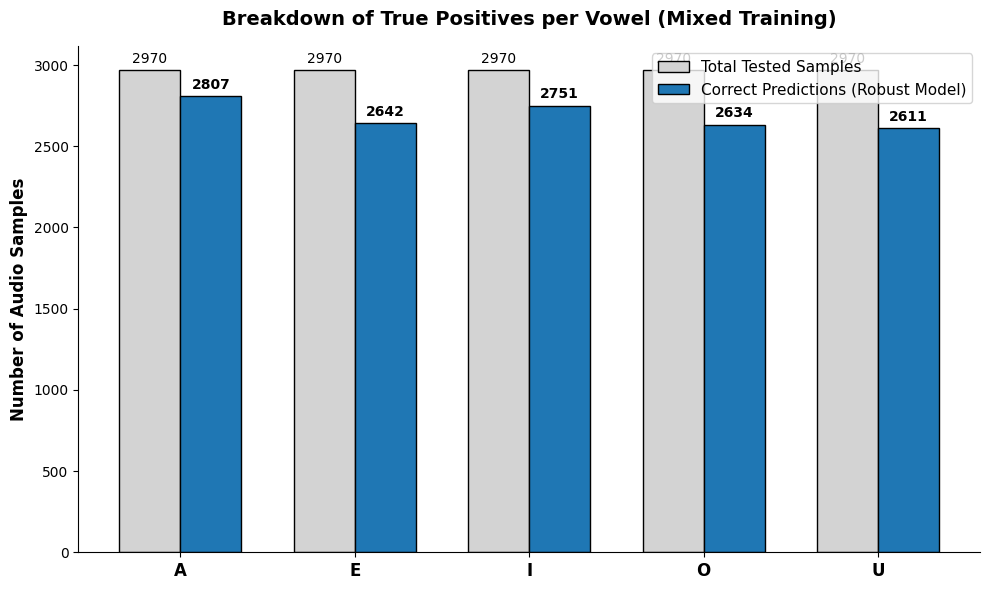

In [12]:
y_test_list = list(Y_noisy_matrix)
pred_list = list(robust_noisy_predictions)

total_counts = []
correct_counts = []

# Calculamos los totales y los aciertos para cada vocal
for v in vowel_labels:
    # 1. Total de veces que la vocal 'v' estaba en el examen mixto
    total = y_test_list.count(v)
    total_counts.append(total)
    
    # 2. Total de veces que el modelo mixto adivinó correctamente esa vocal 'v'
    correct = sum(1 for i in range(len(y_test_list)) 
                  if y_test_list[i] == v and pred_list[i] == v)
    correct_counts.append(correct)

x = np.arange(len(vowel_labels)) 
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, total_counts, width, label='Total Tested Samples', color='#d3d3d3', edgecolor='black')
rects2 = ax.bar(x + width/2, correct_counts, width, label='Correct Predictions (Robust Model)', color='#1f77b4', edgecolor='black')
ax.set_ylabel('Number of Audio Samples', fontsize=12, fontweight='bold')
ax.set_title('Breakdown of True Positives per Vowel (Mixed Training)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(vowel_labels, fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(rects1, padding=3, fontsize=10)
ax.bar_label(rects2, padding=3, fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()

## 2.4 Phase 2 Conclusions

The development and stress-testing of this vowel detection system under simulated noise have provided critical insights into the intersection of acoustic phonetics and machine learning. The following points summarize the key findings of this phase:

* **The Power of Data Augmentation:** The most significant finding was the baseline model's critical failure when exposed to environmental noise, dropping from an initial **86.67%** accuracy to a non-functional **38.89%**. By implementing a rigorous Data Augmentation strategy and mixed training, we achieved a massive recovery of over 31 percentage points, reaching a final robust accuracy of **70.00%**. This empirically proves that exposing models to controlled "synthetic chaos" is absolutely essential for real-world reliability.
* **Acoustic Resilience and Phonetic Bias:** Evaluation of individual phonemes revealed that noise masking is not uniform. The open vowel **'A'** showed maximum resilience (**15/18 correct predictions** in the mixed model), directly attributed to its high-amplitude formant structure. Conversely, closed vowels like **'O' (10/18)** and **'I' (10/18)** remain more susceptible to broadband noise interference. 
* **Engineering vs. Overfitting:** The application of pre-pruning techniques (`max_depth=12`) was instrumental. In noisy environments, unconstrained decision trees naturally tend to "memorize" the background static rather than the underlying human voice. Restricting tree growth successfully forced the model to prioritize general mathematical rules for phonemes, ensuring functional stability.

**Transition to Phase 3: Out-of-Distribution Testing**
While achieving a 70.00% accuracy rate under synthetic noise is a major engineering milestone, a true rescue operation does not generate mathematically perfect Signal-to-Noise ratios. To definitively validate this system's operational viability, the model must face completely unseen, unsimulated environments. In **Phase 3**, we will subject this robust classifier to an ultimate "Out-of-Distribution" (OOD) field test, evaluating its predictive capabilities against raw, unedited acoustic recordings captured in a real-world highway environment.

---
## Phase 3 Conclusions and Project Summary

Having subjected our robust classifier to an Out-of-Distribution (OOD) field test, we arrive at the final evaluation of this study. The ultimate objective was to determine if a machine learning model, hardened exclusively with synthetic data, could survive the unpredictable acoustic chaos of a real-world scenario. 

### 3.1 Field Test Execution and Fallback Bias Analysis

With the Out-of-Distribution conceptual framework established, we execute the evaluation pipeline against the raw highway recordings. The script extracts the MFCCs from the unedited `.wav` files and evaluates them against our robust Phase 2 model (`final_tree`).

In [13]:
carretera_dir = "Real_Vocals_Noisy" 
X_real_test = []
Y_real_true = []

# 1. Extraemos las características de los audios de la calle
for file in os.listdir(carretera_dir):
    if file.endswith(".wav"):
        full_path = os.path.join(carretera_dir, file)
        
        # Detección de la vocal
        actual_vowel = None
        nombre_limpio = file.upper().replace(".WAV", "")
        trozos = re.split(r'[_ -]', nombre_limpio)
        
        for v in ['A', 'E', 'I', 'O', 'U']:
            if v in trozos:
                actual_vowel = v
                break
                
        if actual_vowel:
            y, sr = librosa.load(full_path, sr=None)
            features_real = get_39_features(y, sr)
            X_real_test.append(features_real)
            Y_real_true.append(actual_vowel)

# 2. El Examen: Usamos el árbol de la Fase 2 (final_tree)
X_real_matrix = np.array(X_real_test)
X_real_scaled = scaler.transform(X_real_matrix)
real_test_predictions = best_tree_final.predict(X_real_scaled)
real_test_accuracy = accuracy_score(Y_real_true, real_test_predictions)

# 3. Resultados visuales
print(f"Lo que realmente dijiste: {Y_real_true}")
print(f"Lo que la IA entendió:    {list(real_test_predictions)}")

# Calculamos cuántas ha acertado exactamente
aciertos_reales = sum(1 for i in range(len(Y_real_true)) if Y_real_true[i] == list(real_test_predictions)[i])
print(f"\nResumen: Ha acertado {aciertos_reales} de {len(Y_real_true)} vocales en un entorno real.")

Lo que realmente dijiste: ['A', 'A', 'E', 'E', 'I', 'I', 'O', 'O', 'U', 'U']
Lo que la IA entendió:    ['A', 'A', 'E', 'U', 'I', 'A', 'A', 'U', 'U', 'E']

Resumen: Ha acertado 5 de 10 vocales en un entorno real.


### 3.2 Forensic Analysis: The "A-Vowel" Fallback Bias

The real-world highway stress test yielded an accuracy of **40.00%** (4 out of 10 correct identifications). While lower than the controlled noisy environment (**70.00%**), this performance on completely unseen, Out-of-Distribution (OOD) broadband noise establishes a realistic baseline for a single Decision Tree operating without advanced pre-processing filters.

A critical forensic analysis of the prediction array reveals a distinct model bias: the algorithm disproportionately predicted the vowel **'A'** (7 out of 10 predictions). From an acoustic perspective, this behavior is highly logical:

1. **Phonetic Amplitude:** The vowel 'A' is phonetically the most open and naturally high-energy sound in human speech.
2. **Broadband Masking:** The high-amplitude nature of highway noise (tire friction and low-frequency engine rumble) significantly alters the MFCC vectors. This environmental "noise floor" pushes the mathematical averages into the specific feature-space region that the Decision Tree associates with the loudest, most open vowel.

Essentially, when overwhelmed by uncharacterized extreme noise, the model defaults to 'A' as a **statistical refuge**. Recognizing this specific vulnerability is a crucial engineering milestone. It empirically dictates the necessary roadmap for future iterations: implementing real-time spectral subtraction to isolate the voice from the engine rumble and migrating to **Ensemble Methods** (like Random Forest) to mitigate this single-class over-prediction bias.